### Imports

In [1]:
import warnings

import torch

from src.config import CONFIG
from src.run_train import train_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.CNN
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

Loading 30000 spectrograms...


[I 2026-03-25 18:48:23,757] A new study created in memory with name: no-name-610fb028-ee21-4f19-a7ee-0c666896a0fb


Finished loading spectrograms.
Running hyperparameter sweep...


[I 2026-03-25 18:48:57,605] Trial 0 finished with value: 61.4 and parameters: {'lr': 0.00018556168536752228}. Best is trial 0 with value: 61.4.
[I 2026-03-25 18:49:05,348] Trial 1 finished with value: 57.4 and parameters: {'lr': 0.0001849116123976861}. Best is trial 0 with value: 61.4.
[I 2026-03-25 18:49:13,102] Trial 2 finished with value: 58.4 and parameters: {'lr': 0.0002316918061601764}. Best is trial 0 with value: 61.4.
[I 2026-03-25 18:49:20,852] Trial 3 finished with value: 86.0 and parameters: {'lr': 0.003994060252592419}. Best is trial 3 with value: 86.0.
[I 2026-03-25 18:49:29,086] Trial 4 finished with value: 92.96666666666667 and parameters: {'lr': 0.003005212583030892}. Best is trial 4 with value: 92.96666666666667.
[I 2026-03-25 18:49:36,827] Trial 5 finished with value: 82.6 and parameters: {'lr': 0.0013866027272043805}. Best is trial 4 with value: 92.96666666666667.
[I 2026-03-25 18:49:44,531] Trial 6 finished with value: 79.8 and parameters: {'lr': 0.00069297602985524

Hyperparameter sweep completed.
Accuracy: 92.97%
Parameters: {'lr': 0.003005212583030892}


### Training

Loading 30000 spectrograms...
Finished loading spectrograms.
Hyperparameters used: {'lr': 0.003005212583030892, 'model_init': {}}

Training CNN...
[Epoch 1/50]
Train Loss: 1.66 | Train Accuracy: 52.38% | Val Loss: 1.42 | Val Accuracy: 44.40%
Epoch Duration: 24s | Total Time Elapsed: 24s

[Epoch 2/50]
Train Loss: 0.88 | Train Accuracy: 78.90% | Val Loss: 0.82 | Val Accuracy: 75.13%
Epoch Duration: 2s | Total Time Elapsed: 26s

[Epoch 3/50]
Train Loss: 0.56 | Train Accuracy: 86.65% | Val Loss: 0.58 | Val Accuracy: 84.27%
Epoch Duration: 2s | Total Time Elapsed: 28s

[Epoch 4/50]
Train Loss: 0.38 | Train Accuracy: 91.89% | Val Loss: 0.48 | Val Accuracy: 85.13%
Epoch Duration: 2s | Total Time Elapsed: 29s

[Epoch 5/50]
Train Loss: 0.27 | Train Accuracy: 94.93% | Val Loss: 0.38 | Val Accuracy: 88.67%
Epoch Duration: 2s | Total Time Elapsed: 31s

[Epoch 6/50]
Train Loss: 0.20 | Train Accuracy: 96.28% | Val Loss: 0.52 | Val Accuracy: 82.83%
Epoch Duration: 2s | Total Time Elapsed: 32s

[Epoch

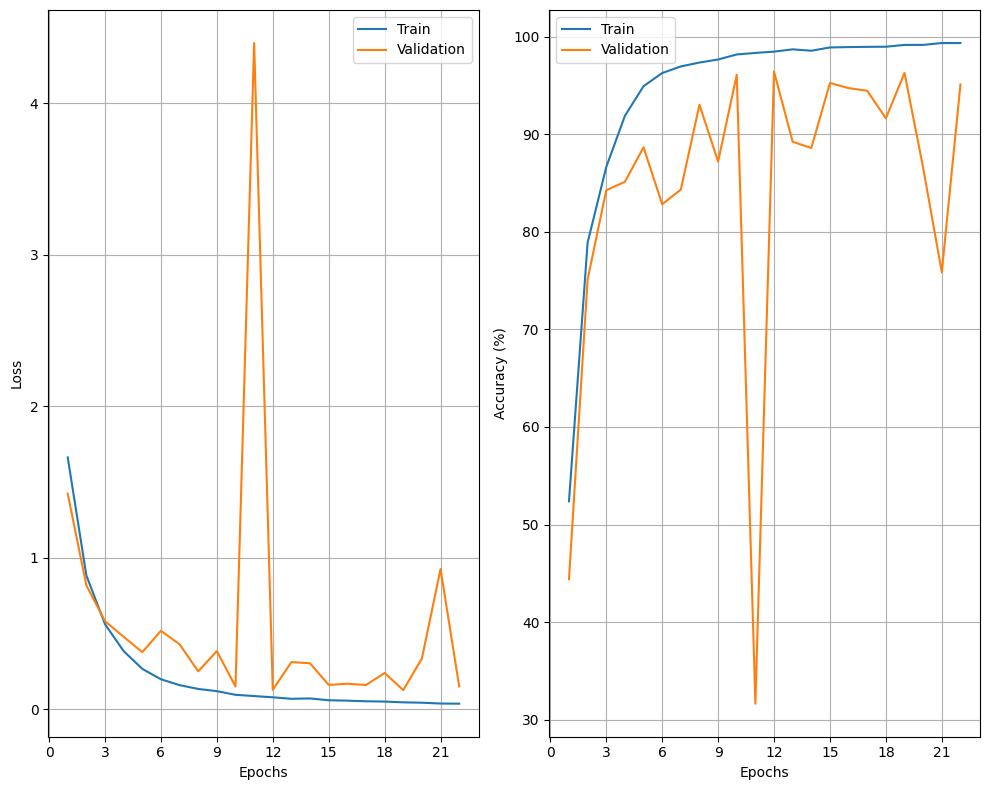

In [5]:
results = train_and_benchmark(device, MODEL, DATASET, FILTERBANK)
plot_training_history(**results['epoch_history'])